# Arbitrage index

Given the reference trade sizes, price the executable cross-pool round trip and
summarize it into a per-pool-pair arbitrage index. Parameters come from
`arblib.config.STUDY`.

In [1]:
from arblib import data_io, analysis, sizing, arbitrage, modeling, plotting
from arblib.config import STUDY as S

pools = data_io.load_processed_pools(S.processed_dir)
analysis.add_mid_price(pools)

x_usd = data_io.load_price_series(S.x_price_path)
y_usd = data_io.load_price_series(S.y_price_path)
price0, price1 = sizing.constant_usd_prices(x_usd, y_usd)

quantiles = data_io.load_quantiles(S.quantiles_path)
print(quantiles)

Loaded 7 processed pools: ['uniswap_1', 'uniswap_2', 'uniswap_3', 'uniswap_4', 'uniswap_5', 'pancake_1', 'pancake_2']
quantile
0.2     20.122969
0.4     53.289795
0.6    207.252162
0.8    588.429308
Name: usd, dtype: float64


## 1. Cross-DEX mid-price gaps

The raw opportunity before execution costs: per-pool mid prices and the absolute
price difference for every cross-DEX pool pair.

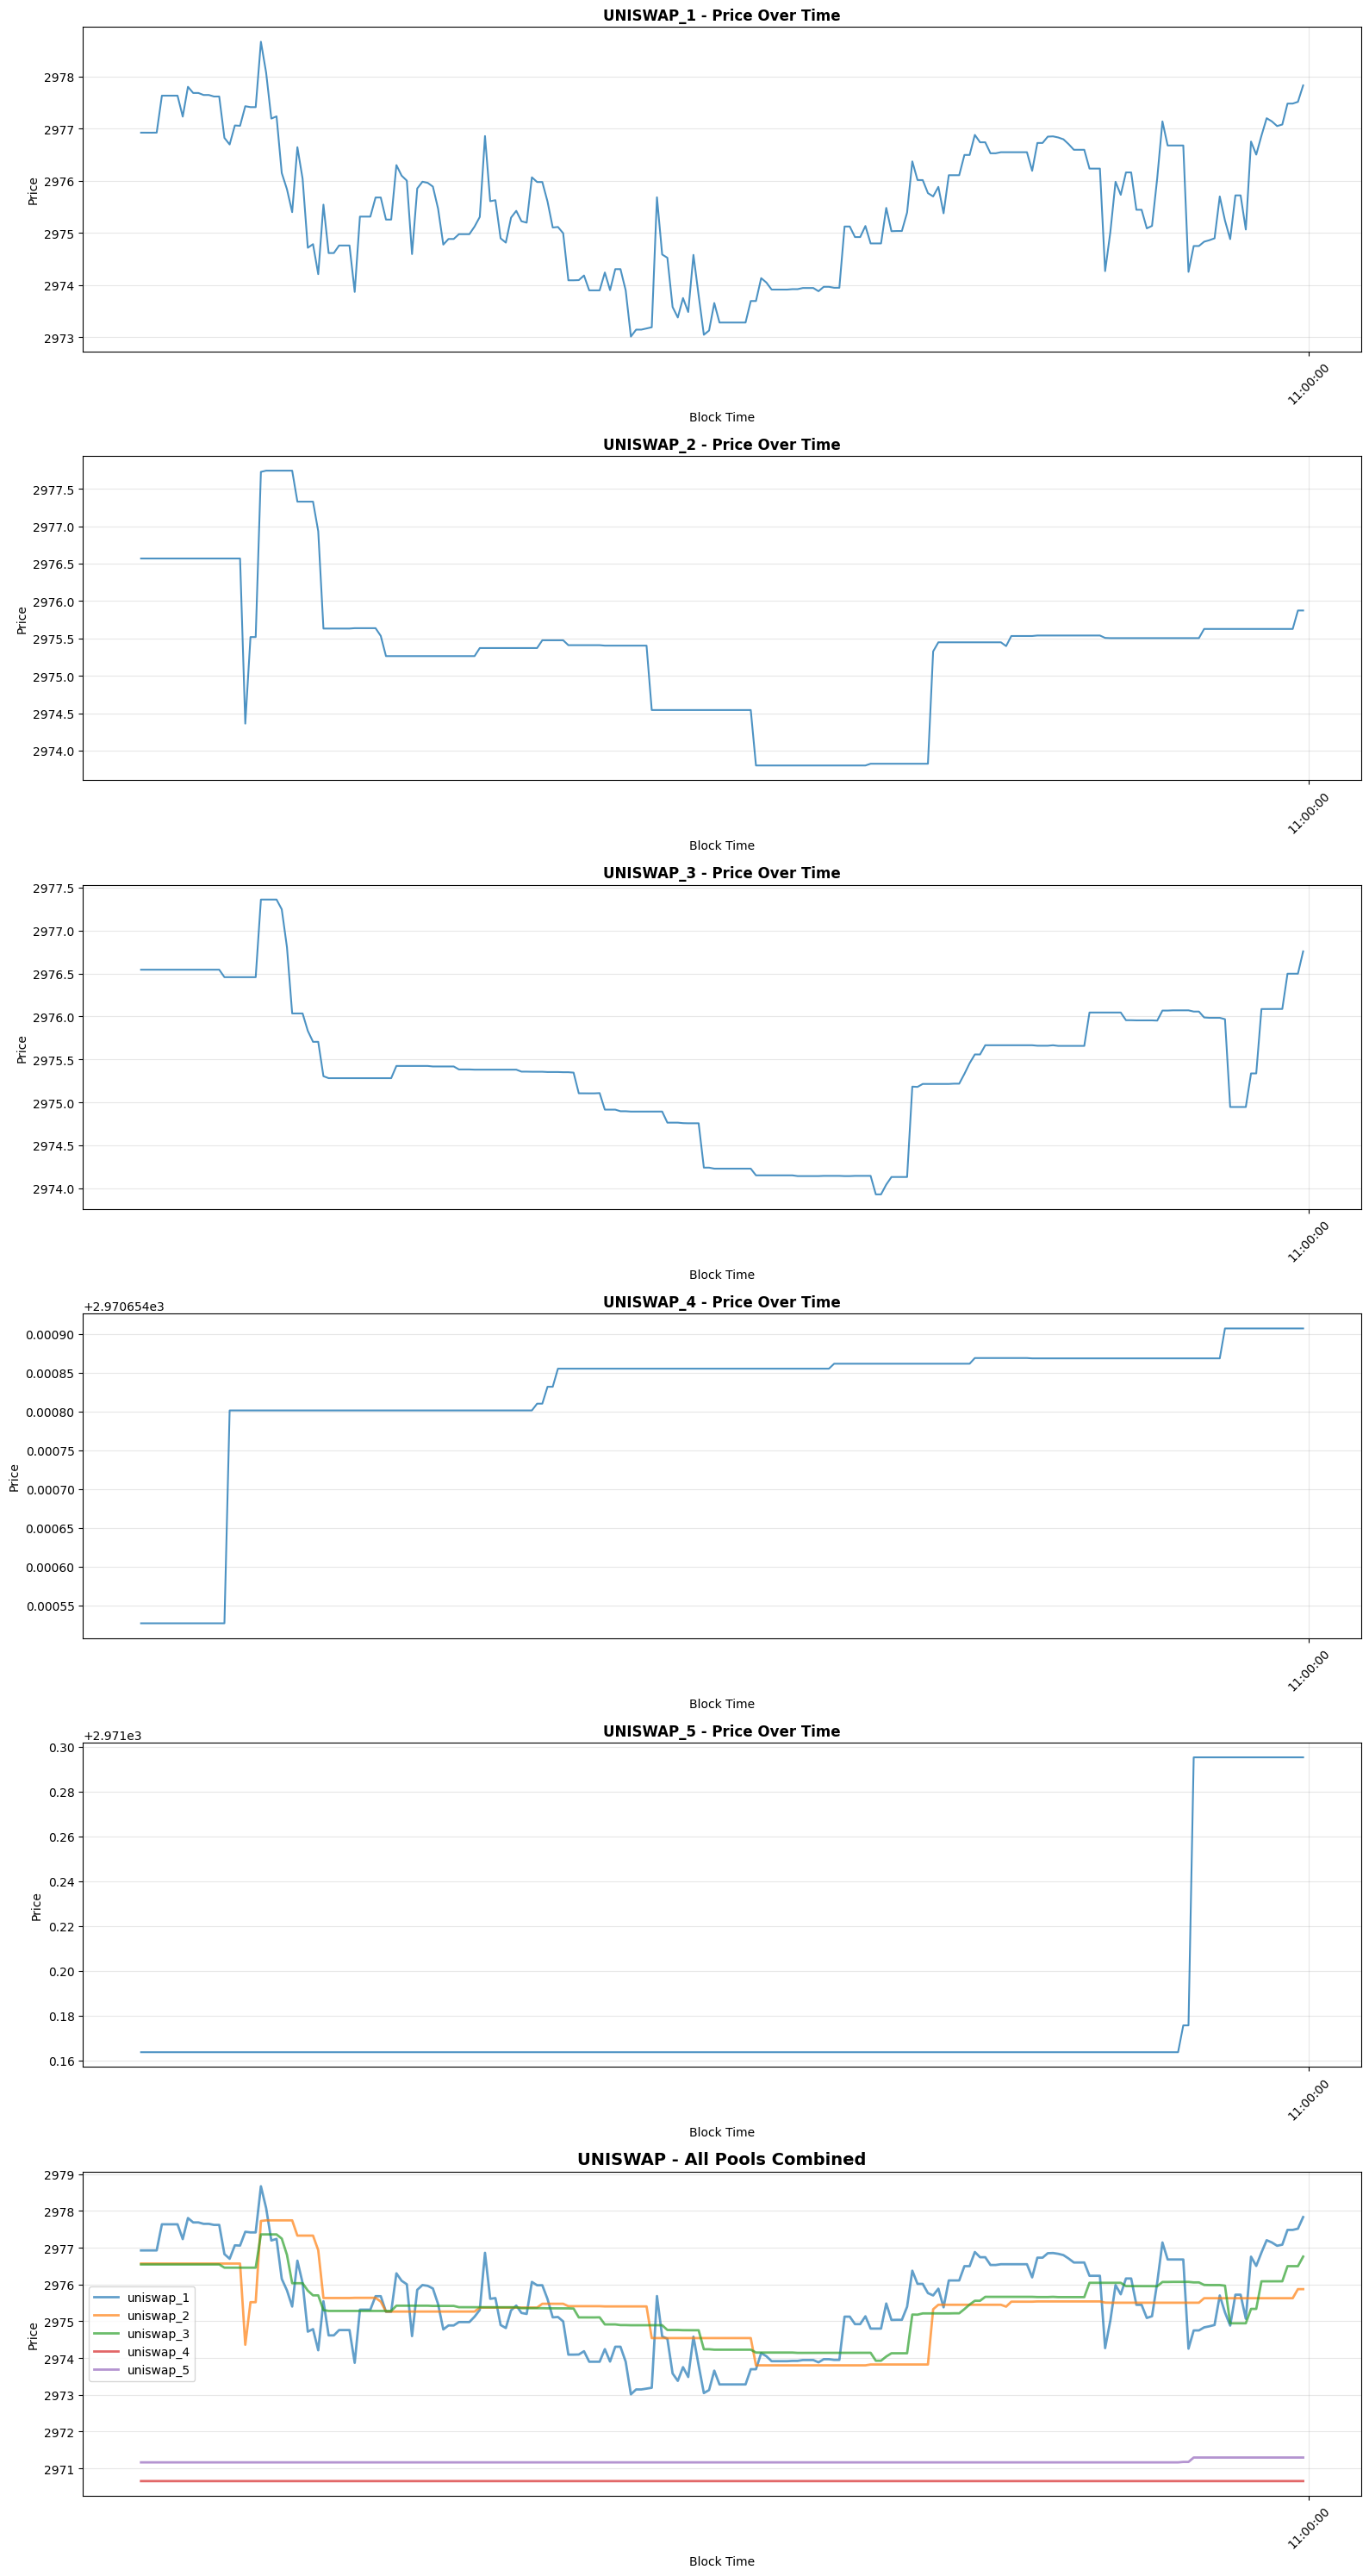


Plotted 5 uniswap pools + 1 combined view
  uniswap_1: 224 blocks
  uniswap_2: 224 blocks
  uniswap_3: 224 blocks
  uniswap_4: 224 blocks
  uniswap_5: 224 blocks


In [2]:
plotting.plot_dex_pools(pools, dex="uniswap")

In [3]:
price_differences, all_price_differences = analysis.compute_pairwise_differences(pools)

DEXes found: ['uniswap', 'pancake']
Pools per DEX: [('uniswap', 5), ('pancake', 2)]

Computed 10 pairwise comparisons:

uniswap_1_vs_pancake_1:
  Rows: 224
  Max diff: 2.070869
  Mean diff: 0.402191
  Min diff: 0.000000

uniswap_1_vs_pancake_2:
  Rows: 224
  Max diff: 2.363094
  Mean diff: 0.911390
  Min diff: 0.001610

uniswap_2_vs_pancake_1:
  Rows: 224
  Max diff: 2.546854
  Mean diff: 0.836410
  Min diff: 0.008160

uniswap_2_vs_pancake_2:
  Rows: 224
  Max diff: 1.913599
  Mean diff: 0.268381
  Min diff: 0.000000

uniswap_3_vs_pancake_1:
  Rows: 224
  Max diff: 1.738813
  Mean diff: 0.661032
  Min diff: 0.004250

uniswap_3_vs_pancake_2:
  Rows: 224
  Max diff: 1.148149
  Mean diff: 0.303594
  Min diff: 0.001731

uniswap_4_vs_pancake_1:
  Rows: 224
  Max diff: 7.946796
  Mean diff: 4.865278
  Min diff: 1.755263

uniswap_4_vs_pancake_2:
  Rows: 224
  Max diff: 6.754006
  Mean diff: 4.773655
  Min diff: 3.112034

uniswap_5_vs_pancake_1:
  Rows: 224
  Max diff: 7.438004
  Mean diff: 4.

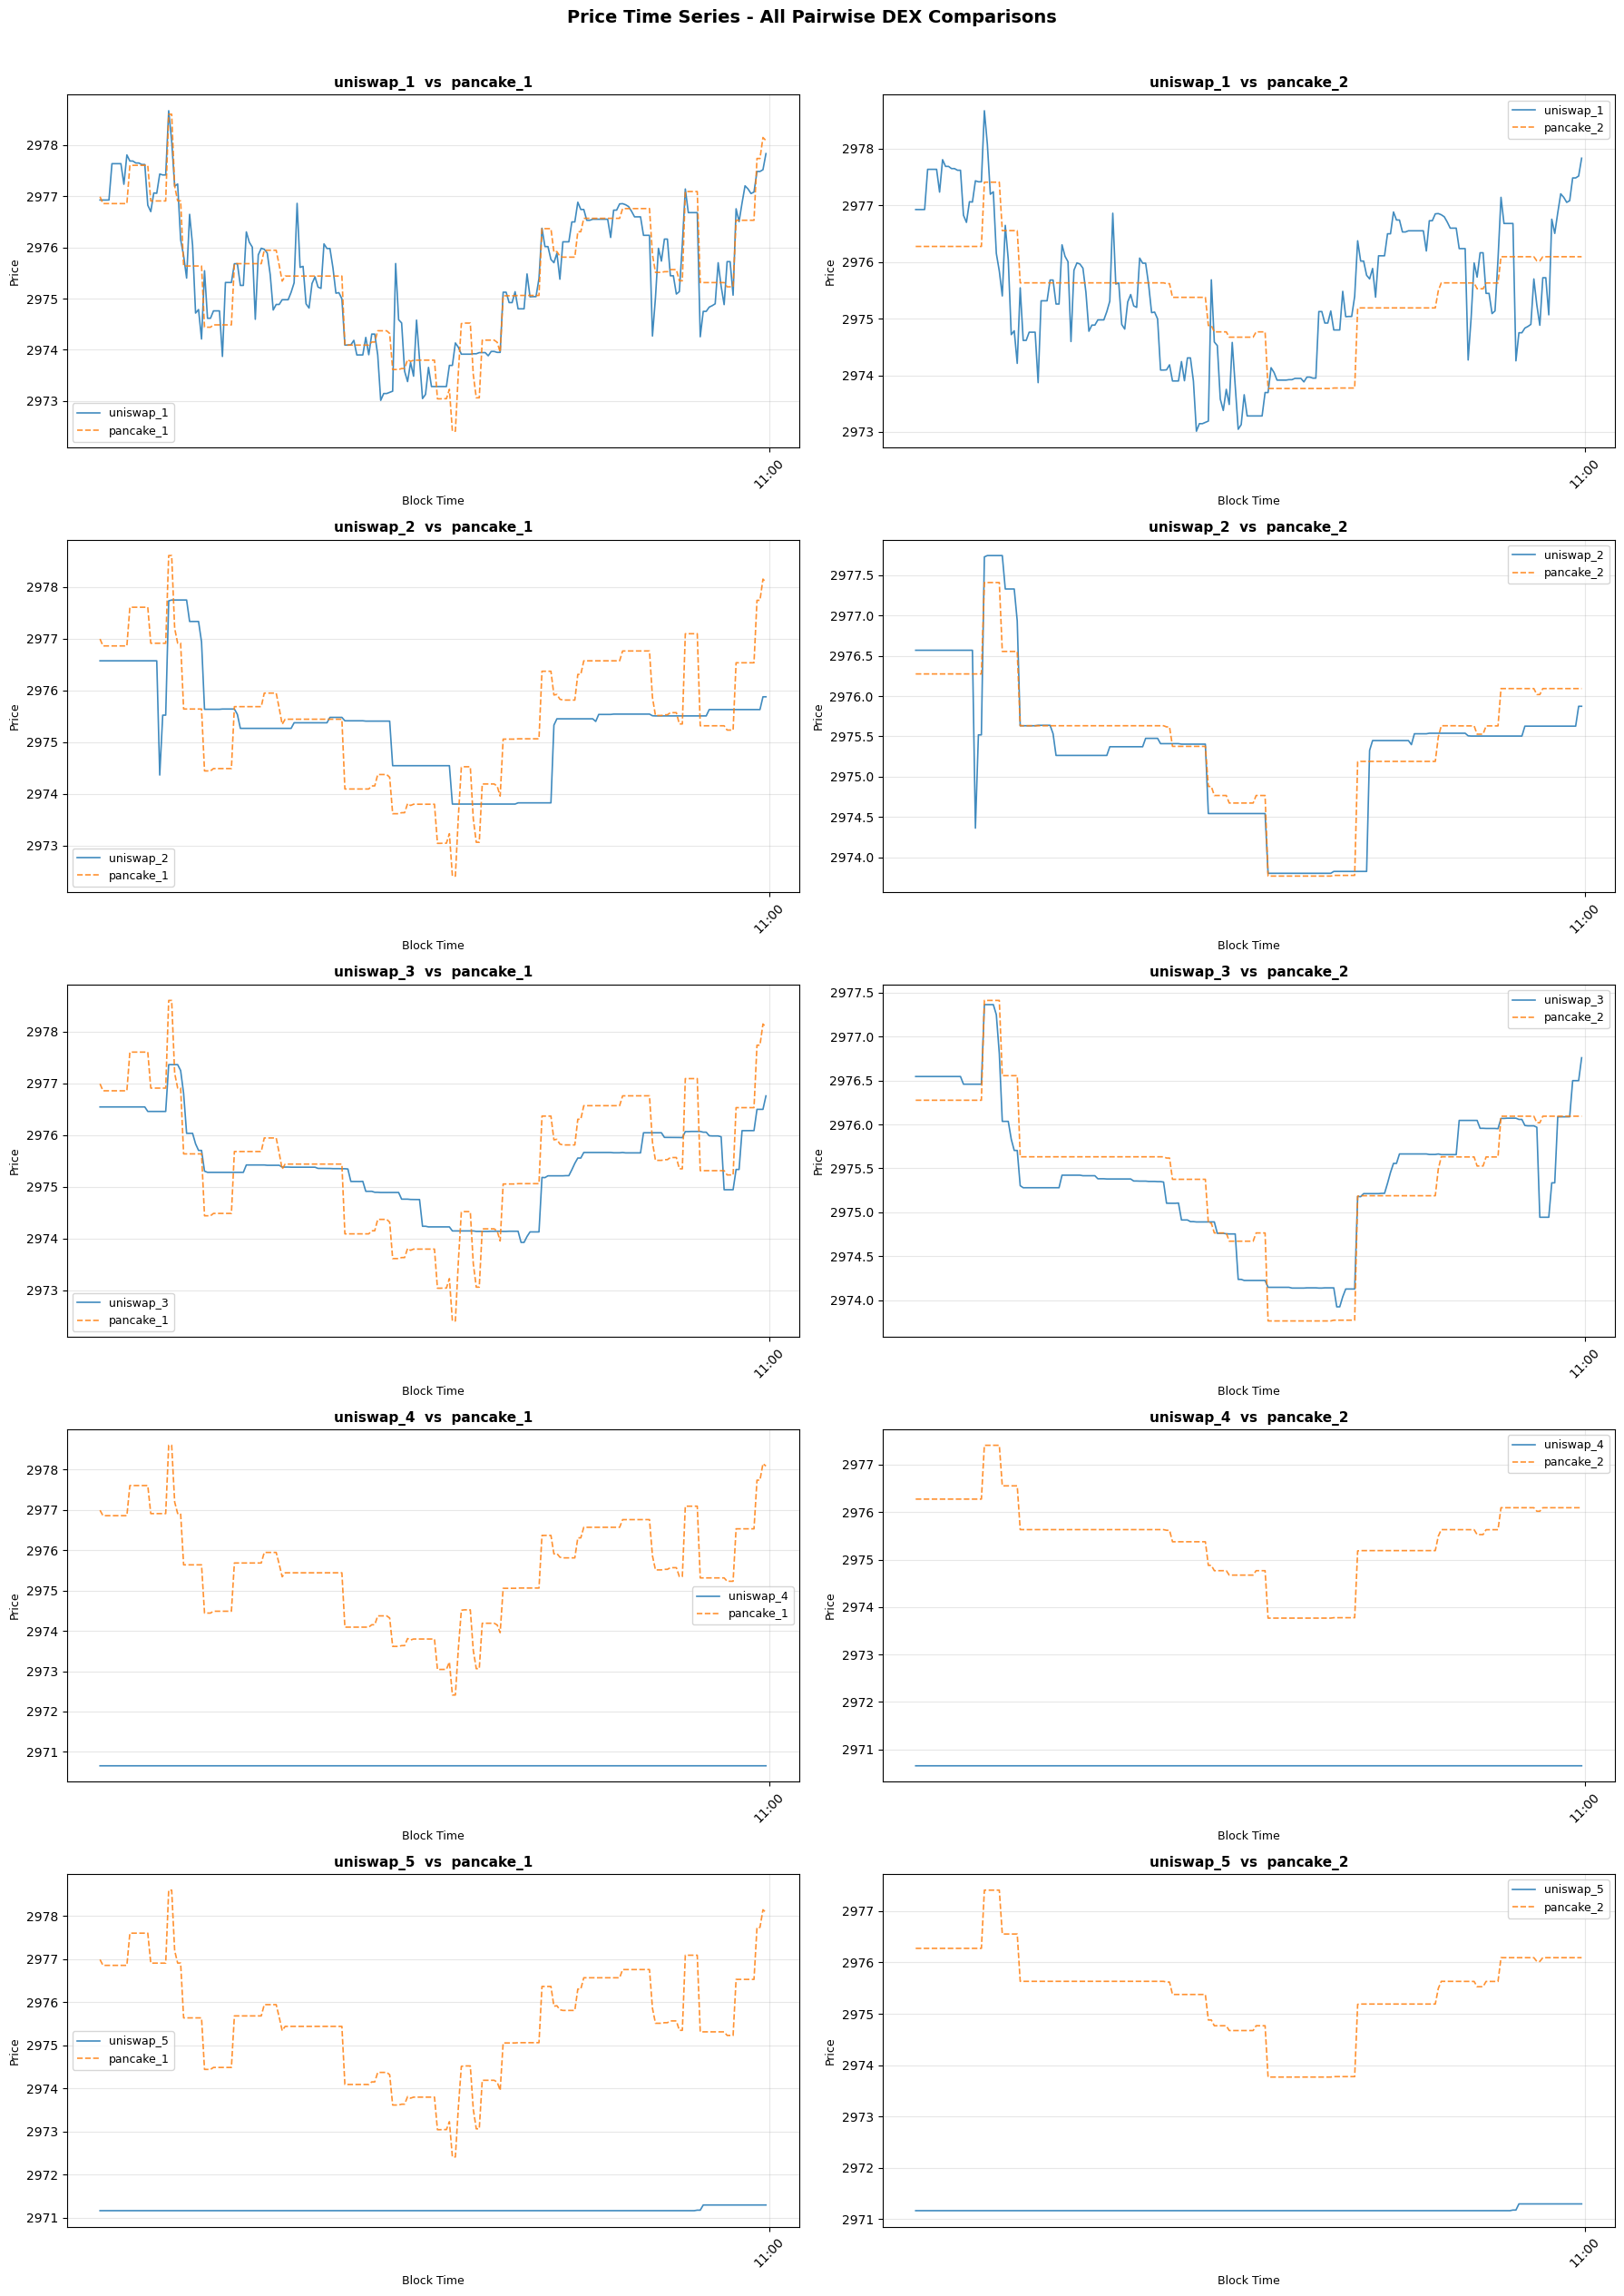

In [4]:
plotting.plot_pairwise_prices(price_differences)

## 2. Pick a pool pair

Bundle two pools' per-block state + market context into a `PoolPair`.

In [5]:
pair = arbitrage.build_pool_pair(
    pools["pancake_1"], pools["uniswap_1"], S.token0, S.token1, price0, price1, "pancake_1", "uniswap_1"
)

## 3a. Round-trip spreads at each reference trade size

Two panels per size (direction 1→2 and 2→1, Y- and X-anchored). A series below
zero is a profitable round trip after both fees + slippage.

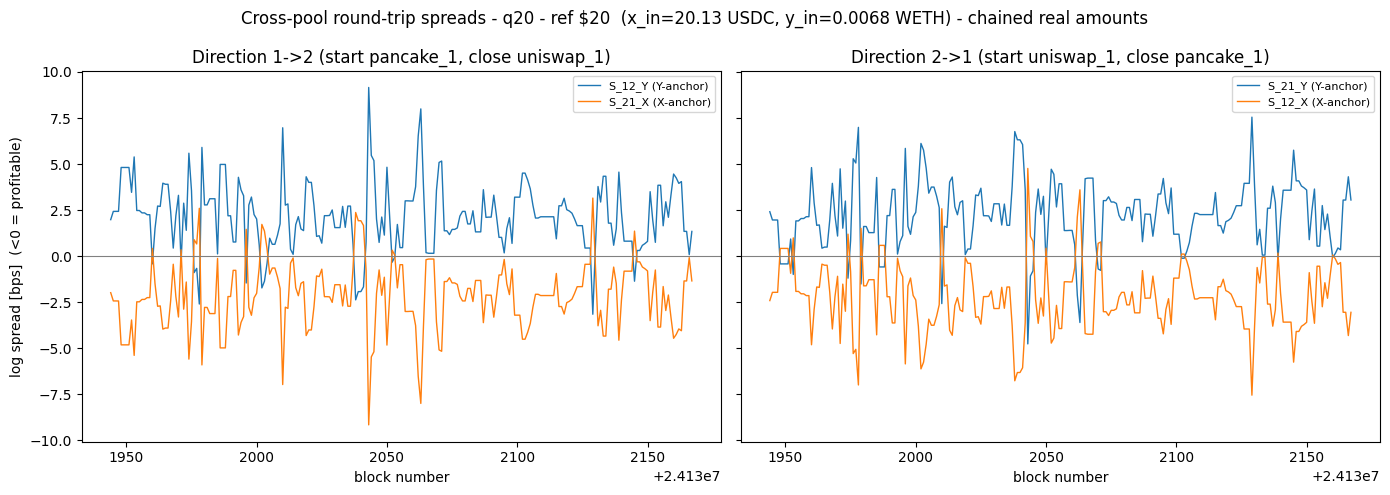

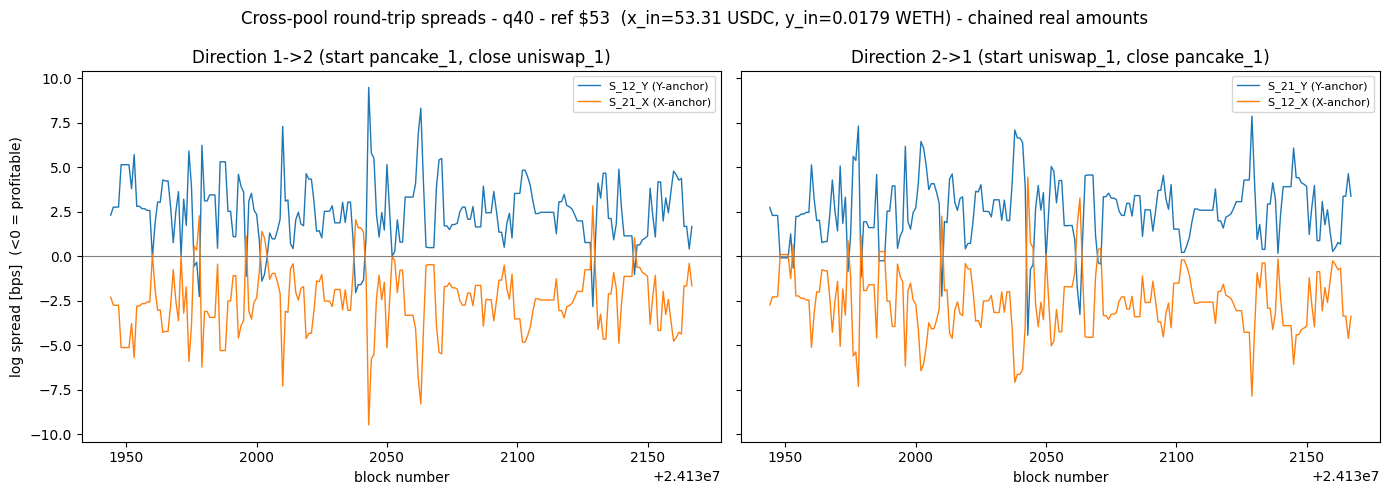

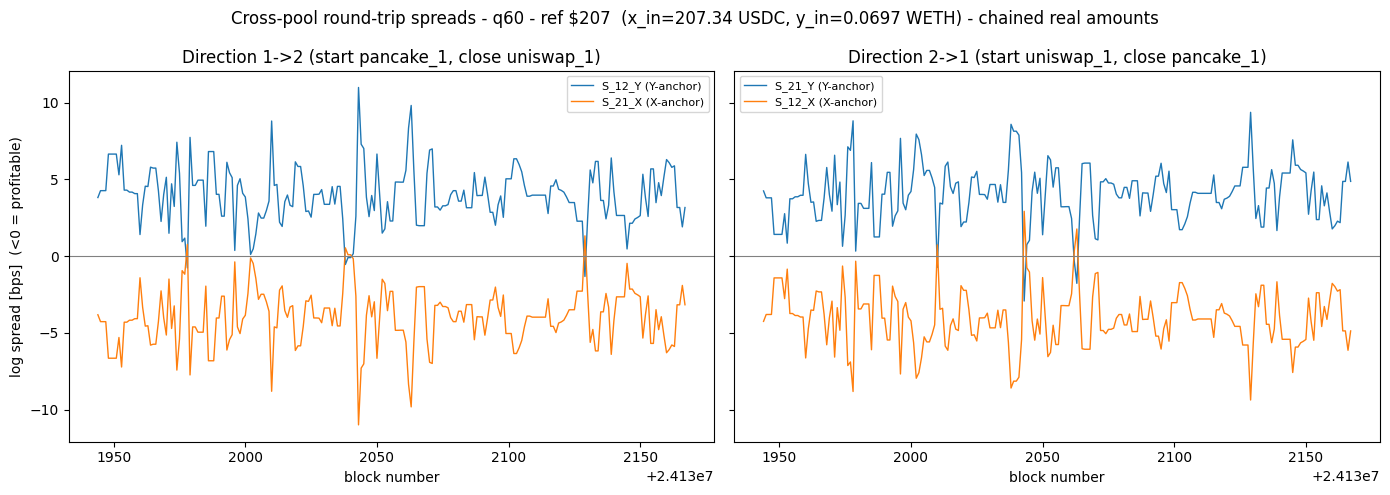

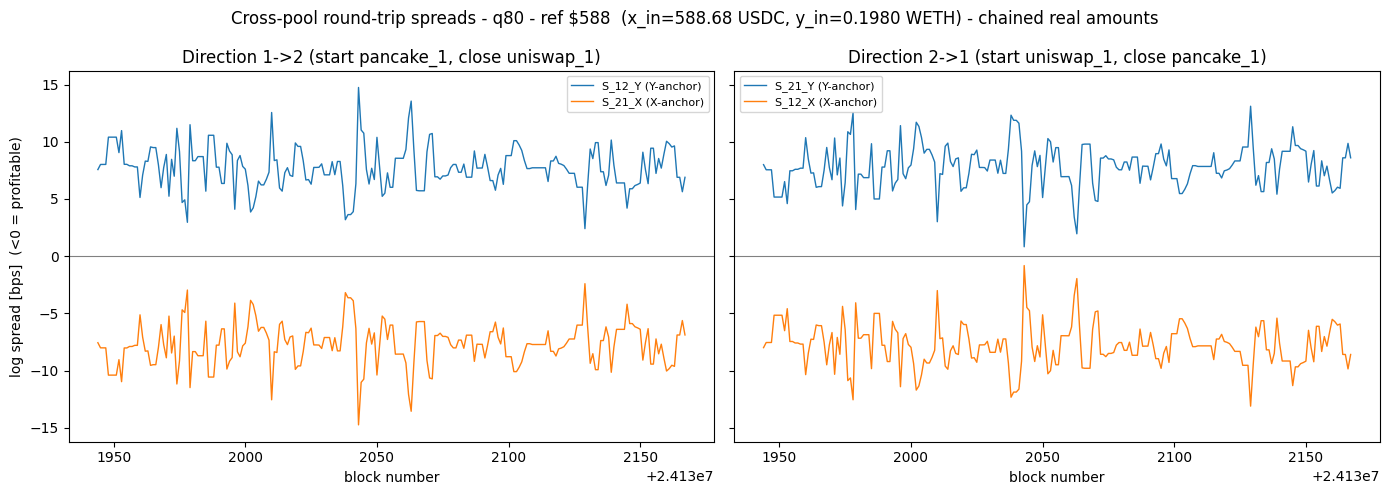

In [6]:
for q, Q in quantiles.items():
    plotting.plot_directional_spreads(pair, Q, f"Cross-pool round-trip spreads - q{int(q * 100)}")

## 3b. Custom trade size

Pass exactly one of `usd_amount` / `x_amount` (token0) / `y_amount` (token1).

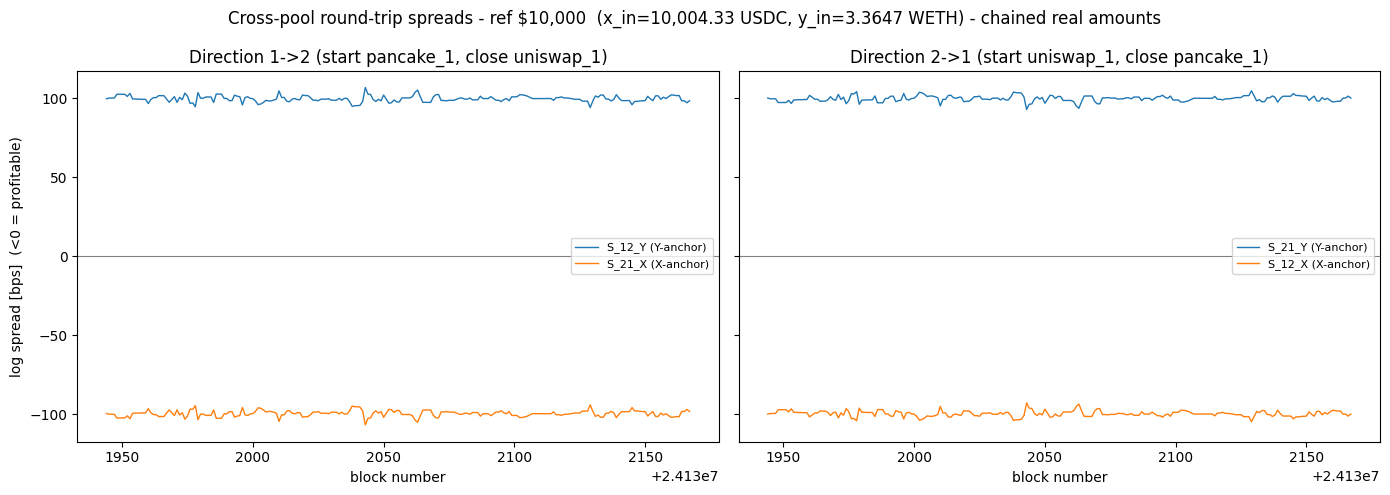

In [7]:
plotting.plot_custom_size(pair, usd_amount=10_000, title_prefix="Cross-pool round-trip spreads")

## 4. Arbitrage index (all pool pairs)

`all_pairs_gap_series` stores the per-block round-trip gap `Gap_t` (bps) for **every**
pool pair — intra-DEX (e.g. `uniswap_1_vs_uniswap_5`) as well as cross-DEX.
`arb_index["<poolA>_vs_<poolB>"]` is a blocks × trade-sizes frame; `arbitrage_index`
below summarises one pair across blocks.

In [8]:
arb_index = arbitrage.all_pairs_gap_series(pools, quantiles, S.token0, S.token1, price0, price1)
print("pairs:", list(arb_index))
arb_index["uniswap_1_vs_uniswap_5"].head(10)



pairs: ['uniswap_1_vs_uniswap_2', 'uniswap_1_vs_uniswap_3', 'uniswap_1_vs_uniswap_4', 'uniswap_1_vs_uniswap_5', 'uniswap_1_vs_pancake_1', 'uniswap_1_vs_pancake_2', 'uniswap_2_vs_uniswap_3', 'uniswap_2_vs_uniswap_4', 'uniswap_2_vs_uniswap_5', 'uniswap_2_vs_pancake_1', 'uniswap_2_vs_pancake_2', 'uniswap_3_vs_uniswap_4', 'uniswap_3_vs_uniswap_5', 'uniswap_3_vs_pancake_1', 'uniswap_3_vs_pancake_2', 'uniswap_4_vs_uniswap_5', 'uniswap_4_vs_pancake_1', 'uniswap_4_vs_pancake_2', 'uniswap_5_vs_pancake_1', 'uniswap_5_vs_pancake_2', 'pancake_1_vs_pancake_2']


,0.2,0.4,0.6,0.8
block,,,,
24131944,0.0,0.0,0.0,0.0
24131945,0.0,0.0,0.0,0.0
24131946,0.0,0.0,0.0,0.0
24131947,0.0,0.0,0.0,0.0
24131948,0.0,0.0,0.0,0.0
24131949,0.0,0.0,0.0,0.0
24131950,0.0,0.0,0.0,0.0
24131951,0.0,0.0,0.0,0.0
24131952,0.0,0.0,0.0,0.0


In [9]:
arbitrage.arbitrage_index(pair, quantiles)

,usd_ref,n_blocks,live_gap_share,mean_gap_bps,median_gap_bps,max_gap_bps,anchor_agreement
quantile,,,,,,,
0.2,20.122969,224,0.178571,0.210108,0.0,4.763873,1.0
0.4,53.289795,224,0.156250,0.157030,0.0,4.437950,1.0
0.6,207.252162,224,0.040179,0.038187,0.0,2.925132,1.0
0.8,588.429308,224,0.000000,0.000000,0.0,0.000000,1.0


## 5. Any arbitrage in the sample?

Heatmap of the round-trip gap across all pairs and blocks, one panel per reference
trade size. Coloured cells are profitable round trips (after fees + slippage); a
near-blank map means little arbitrage at that size.

q20: 81 live (pair, block) cells of 4704 | max gap = 4.76 bps


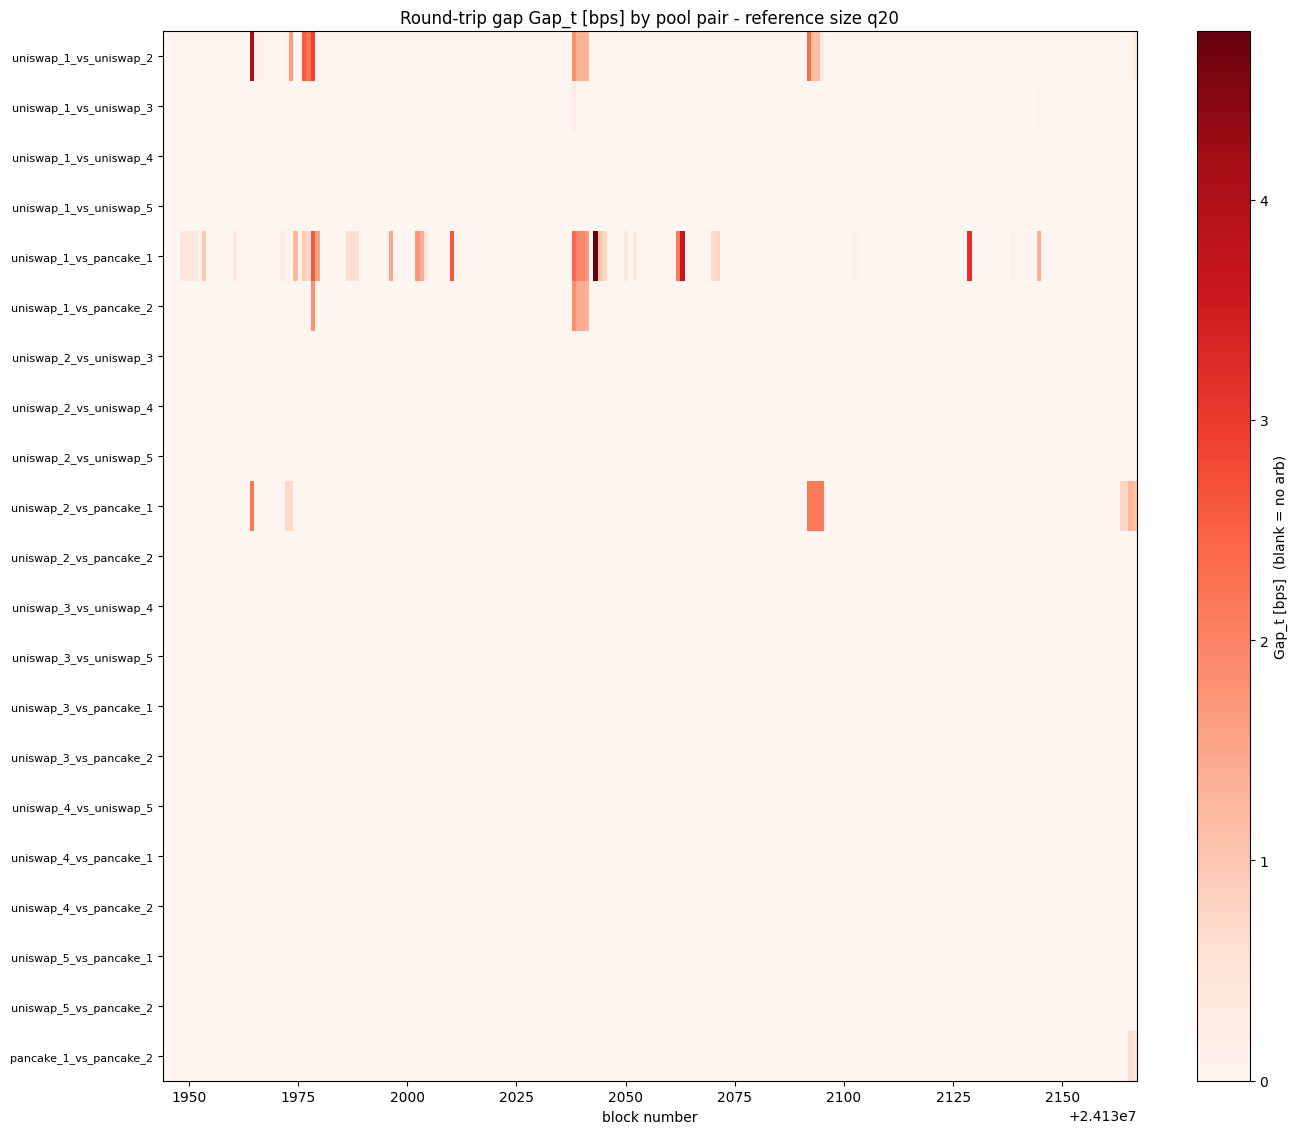

q40: 66 live (pair, block) cells of 4704 | max gap = 4.44 bps


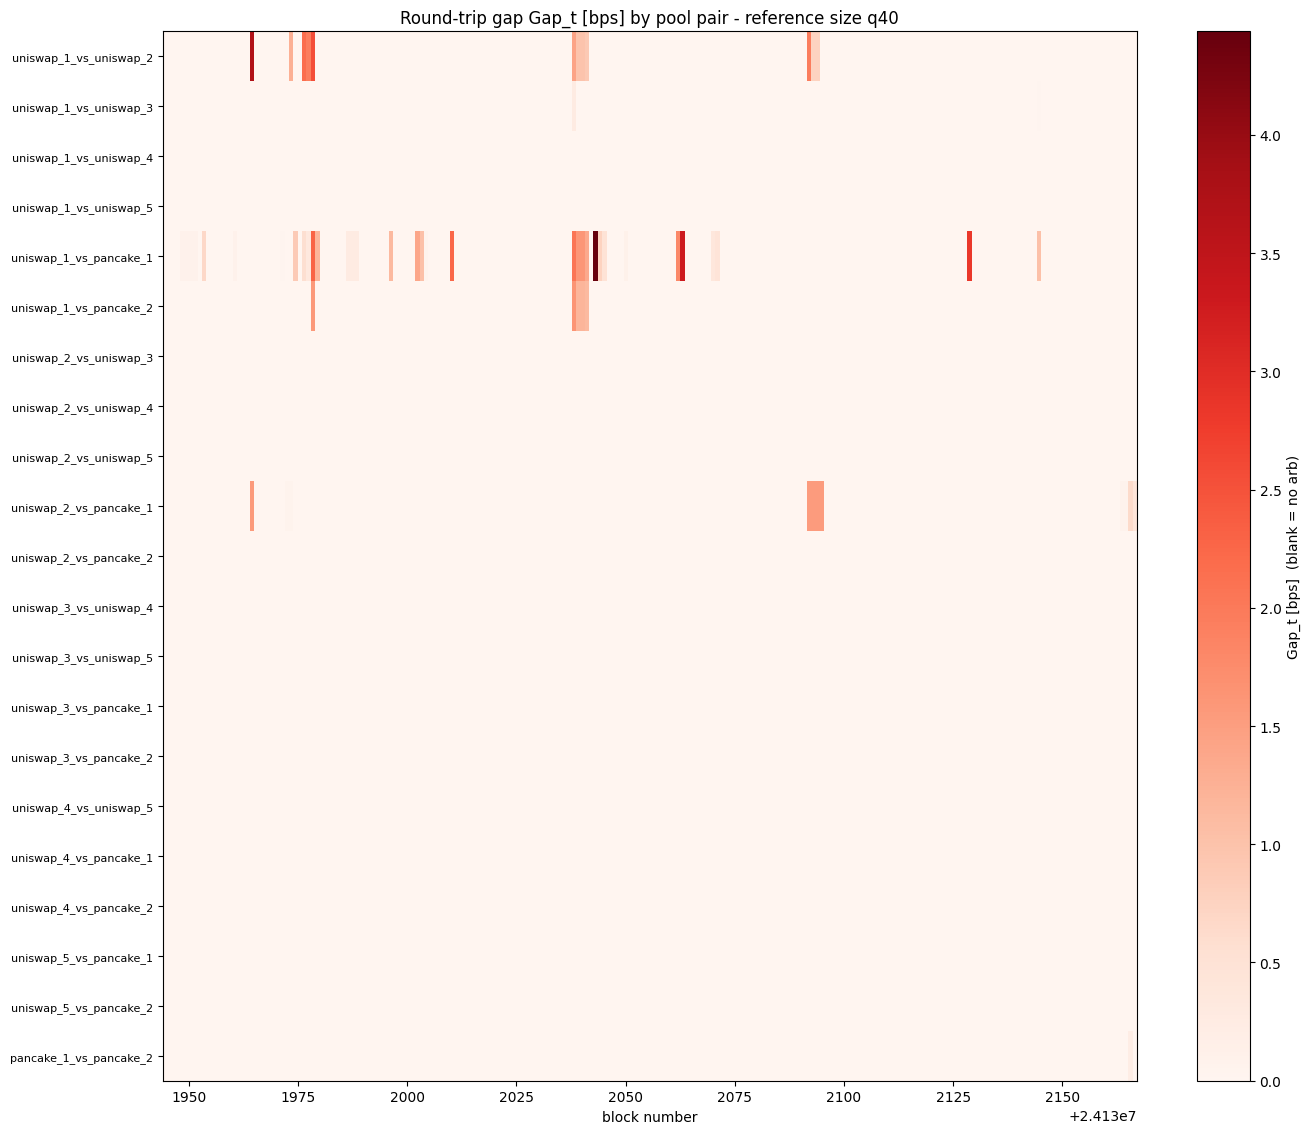

q60: 20 live (pair, block) cells of 4704 | max gap = 2.93 bps


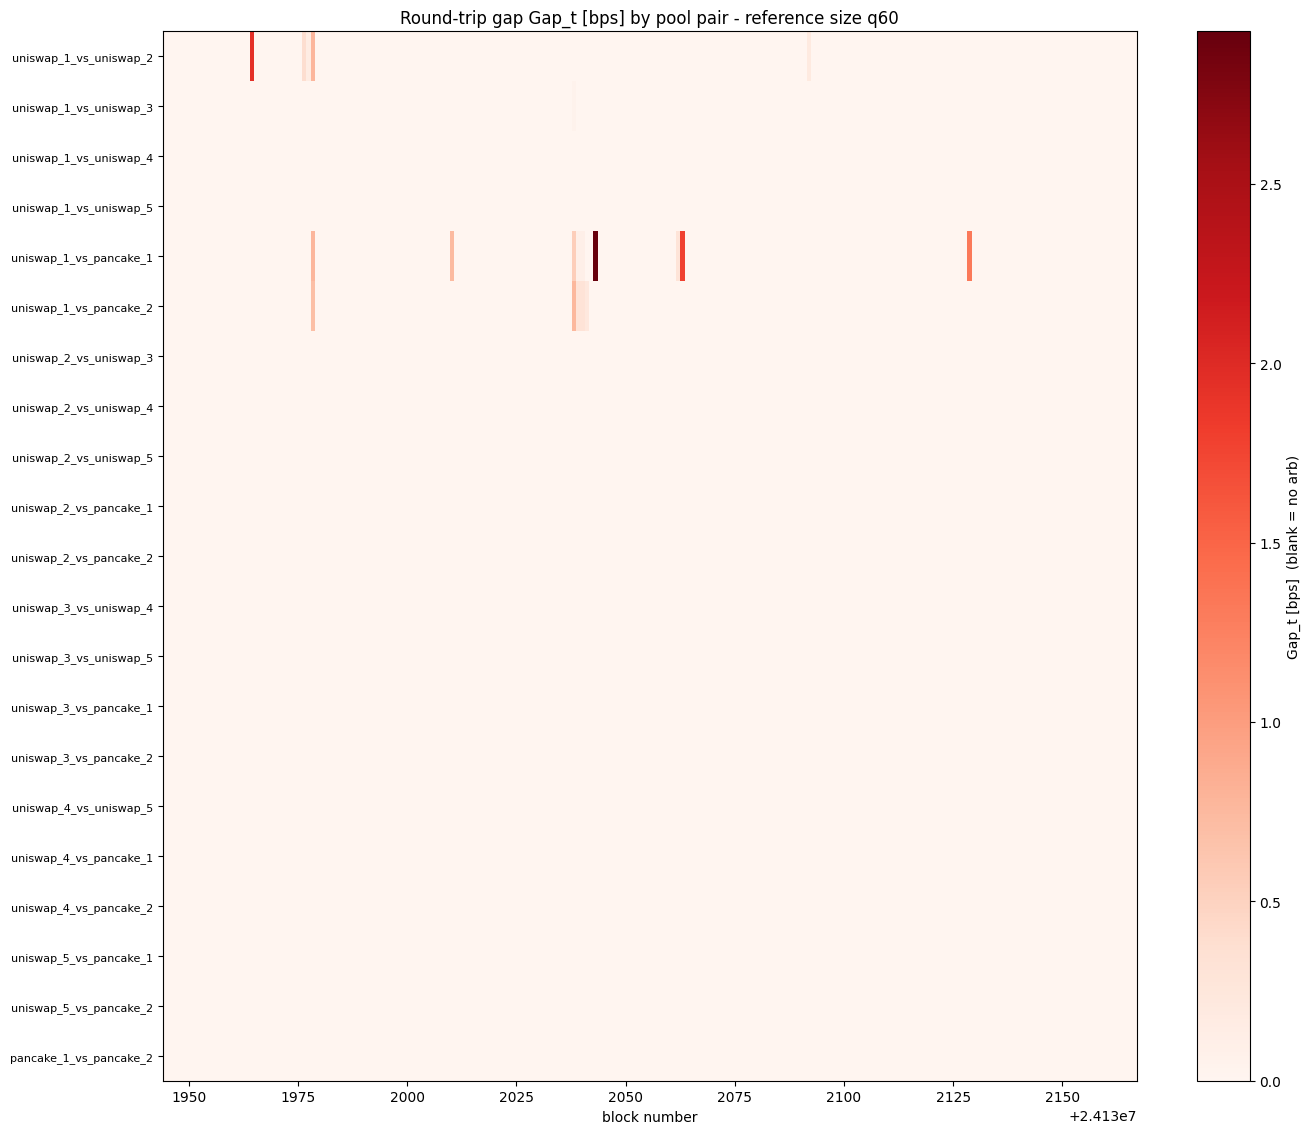

q80: 0 live (pair, block) cells of 4704 | max gap = 0.00 bps


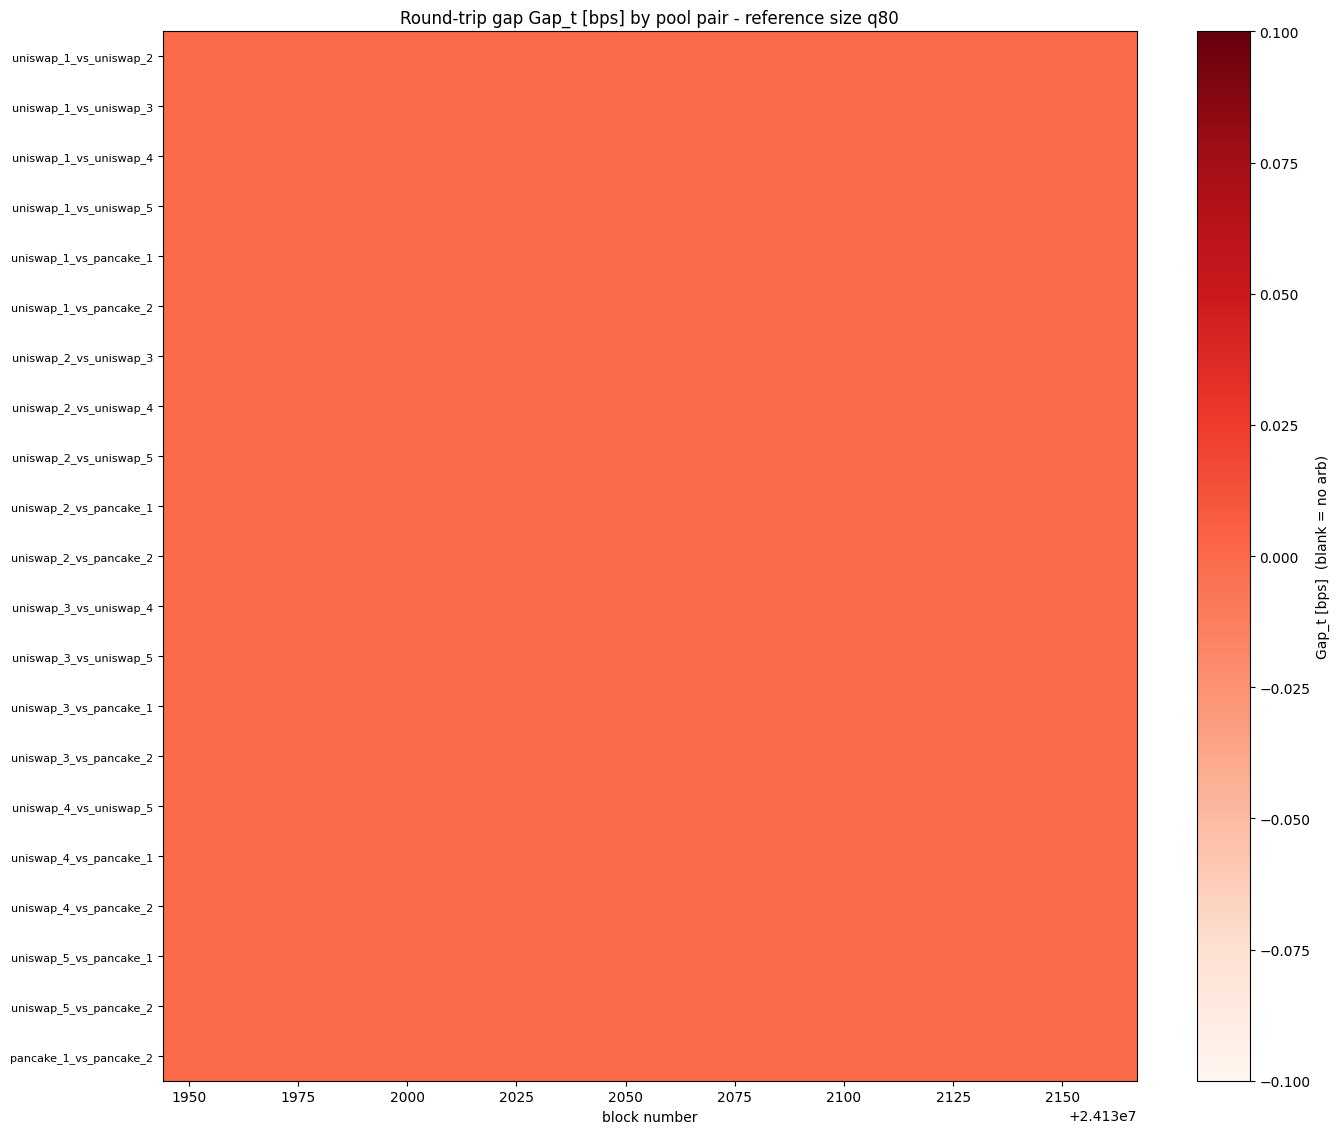

In [10]:
for q in quantiles.index:
    plotting.plot_arb_index(arb_index, q)

## 6. How long does arbitrage hold?

For each pool pair the arbitrage index is live (`Gap_t > 0`) in runs of consecutive
blocks — an arbitrage *spell*. `arb_hold_durations` extracts every spell's length (in
blocks); `plot_arb_durations` draws, **one graph per trade size**, the per-pair duration
**sequence** (x = spell index in order of occurrence, y = duration), e.g. `2, 6, 5, 4, …` —
one line per pool pair, a line's length being that pair's number of spells.

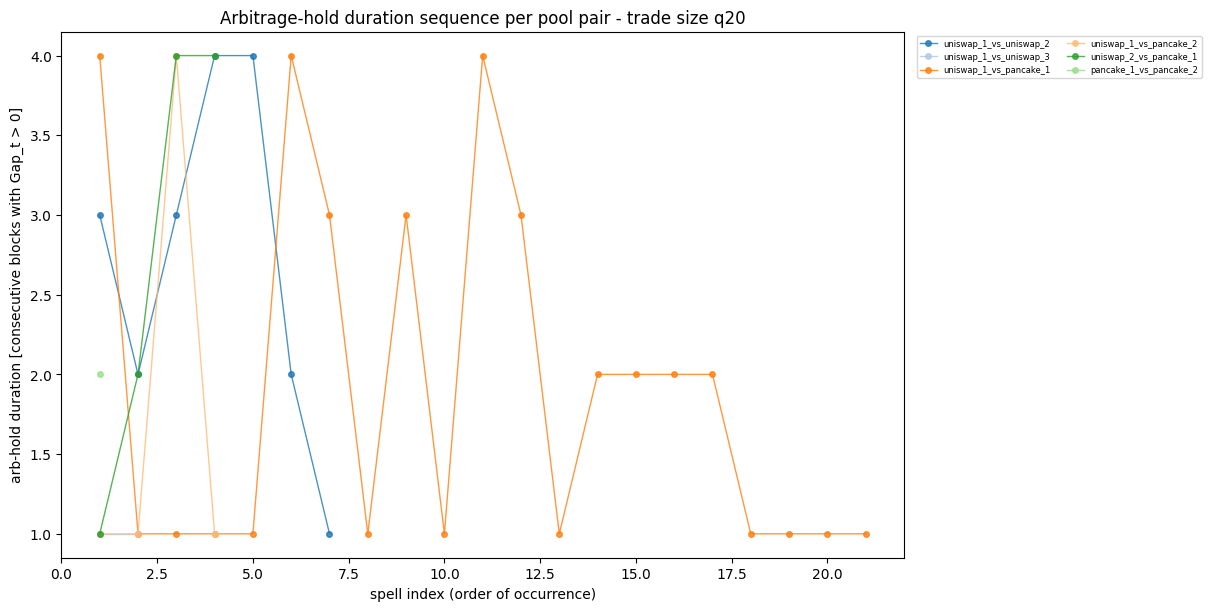

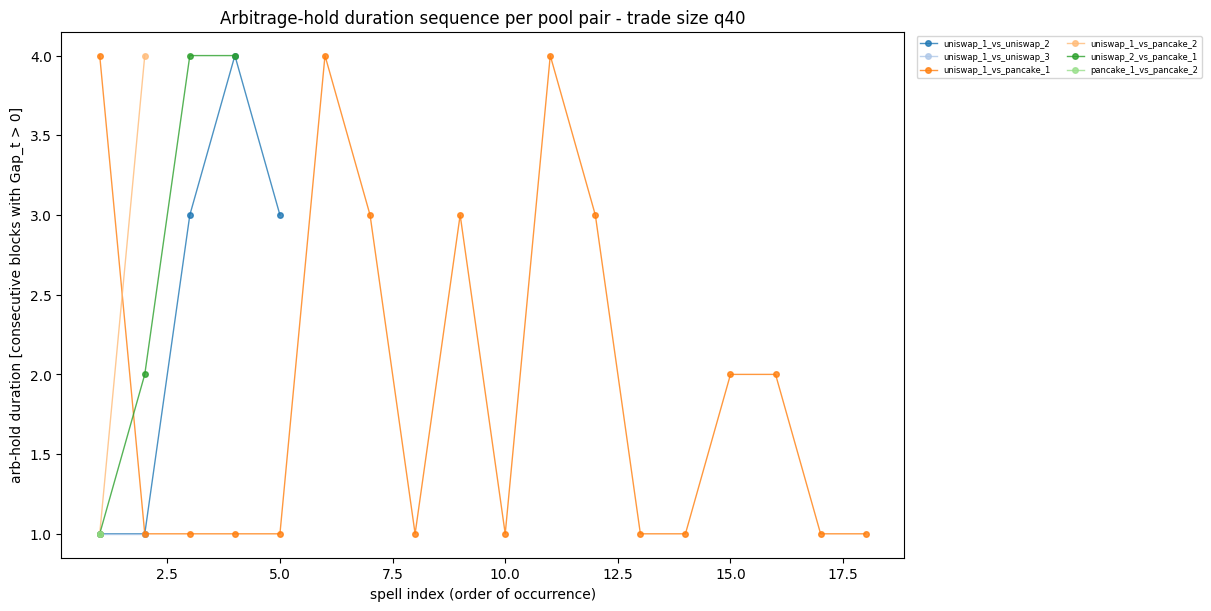

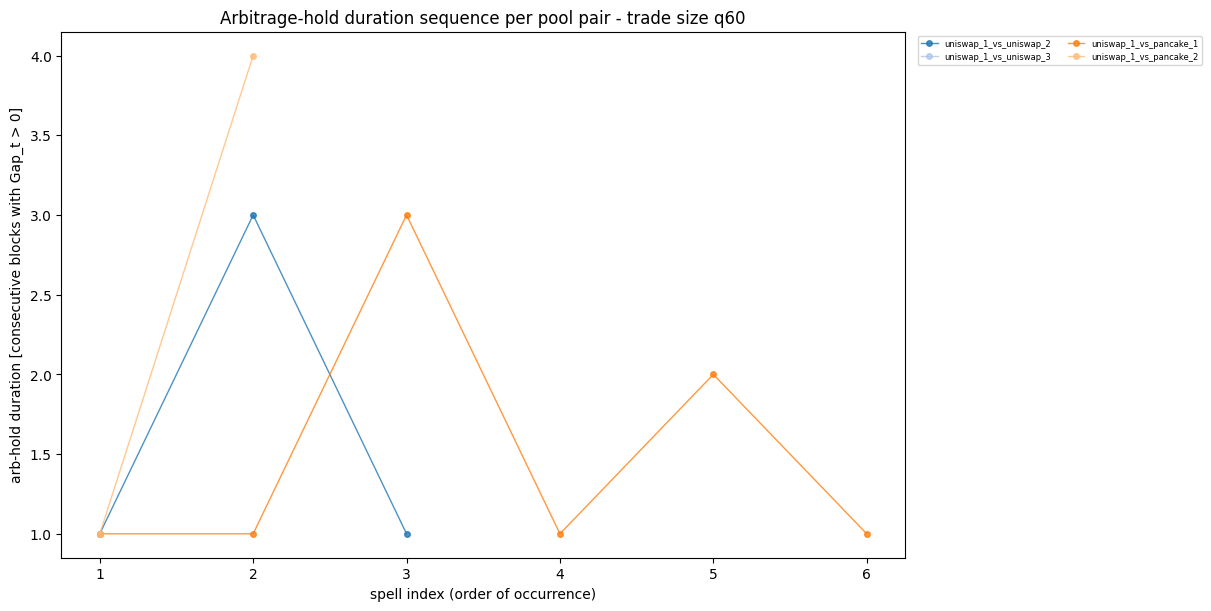

q80: no live arbitrage spells at this trade size


In [11]:
durations = arbitrage.arb_hold_durations(arb_index)
for q in quantiles.index:
    plotting.plot_arb_durations(durations, q)

## 7. Save the dependent variable (one parquet per pool pair)

For every pool pair, persist the panel dependent variable to
`S.dependent_var_dir` (`modeling/dependant_variable/<pair>.parquet`): the continuous
round-trip gap `Gap_t(Q)` (bps) and its binary existence `D_t(Q) = 1[Gap_t(Q) > 0]`
for each reference quantile, keyed by `blocknumber` / `evt_block_time`. Gap is kept
alongside `D` so the same column feeds both the outcome and its own lag downstream.

In [12]:
modeling.save_dependent_variables(arb_index, pools, S.dependent_var_dir)

Saved 21 dependent-variable parquets to /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/WETH_USDC/modeling/dependant_variable


## 8. Save the pool-pair covariates (one parquet per pool pair)

For every pool pair, persist the venue-averaged, pool-pair-dependent covariates to
`S.pair_covariates_dir` (`modeling/covariates/pool_pair_dependant_covariates/<pair>.parquet`):
`mev_intensity` = ½(log(1+mev¹)+log(1+mev²)), `frequency_intensity` = ½(ewma¹+ewma²), and
`per_log_liquidity_growth_rate_avg_venue` = ½(Δlog L¹ + Δlog L²) with Δlog L = log(Lₜ/Lₜ₋₁).
All contemporaneous at block t, keyed by `evt_block_number` / `evt_block_time` — same pair
names as the dependent variable, so the two join 1:1. Lag by one block downstream to make them
predetermined (that lag turns the liquidity term into the model's `mean_dlog_L_{p,t-1}`).

In [13]:
modeling.save_pair_covariates(pools, S.pair_covariates_dir)

Saved 21 pool-pair covariate parquets to /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/WETH_USDC/modeling/covariates/pool_pair_dependant_covariates
